<a href="https://colab.research.google.com/github/SanikaPatil1008/Deep_Learning/blob/main/Exp_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

VAE Epoch 1, Loss: 49.5972
VAE Epoch 2, Loss: 46.7638
VAE Epoch 3, Loss: 45.6958


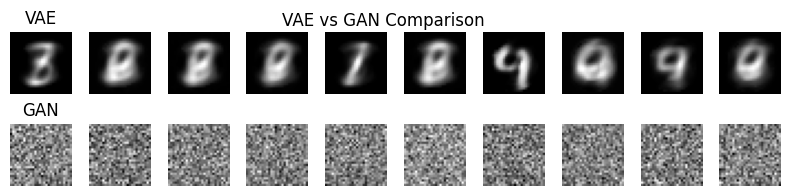

In [11]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# =========================
# DATA
# =========================
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)

# =========================
# SAMPLING LAYER
# =========================
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

# =========================
# ENCODER
# =========================
latent_dim = 2

encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)
z = Sampling()([z_mean, z_log_var])

encoder = tf.keras.Model(encoder_inputs, [z_mean, z_log_var, z])

# =========================
# DECODER
# =========================
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(28*28, activation="sigmoid")(x)
decoder_outputs = layers.Reshape((28, 28, 1))(x)

decoder = tf.keras.Model(latent_inputs, decoder_outputs)

# =========================
# VAE MODEL
# =========================
outputs = decoder(z)
vae = tf.keras.Model(encoder_inputs, outputs)

# =========================
# CUSTOM TRAIN STEP (FIX)
# =========================
optimizer = tf.keras.optimizers.Adam()

@tf.function
def train_step(x):
    with tf.GradientTape() as tape:
        z_mean, z_log_var, z = encoder(x, training=True)
        recon = decoder(z, training=True)

        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - recon), axis=(1,2,3)))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )

        loss = recon_loss + kl_loss

    grads = tape.gradient(loss, vae.trainable_variables)
    optimizer.apply_gradients(zip(grads, vae.trainable_variables))
    return loss

# =========================
# TRAIN VAE
# =========================
batch_size = 128
epochs = 3

dataset = tf.data.Dataset.from_tensor_slices(x_train).batch(batch_size)

for epoch in range(epochs):
    for step, batch in enumerate(dataset):
        loss = train_step(batch)
    print(f"VAE Epoch {epoch+1}, Loss: {loss.numpy():.4f}")

# Generate VAE images
z_sample = np.random.normal(size=(10, 2))
vae_imgs = decoder.predict(z_sample, verbose=0)

# =========================
# GAN
# =========================
def build_generator():
    return tf.keras.Sequential([
        layers.Dense(128, activation="relu", input_dim=100),
        layers.Dense(28*28, activation="sigmoid"),
        layers.Reshape((28,28,1))
    ])

def build_discriminator():
    model = tf.keras.Sequential([
        layers.Flatten(input_shape=(28,28,1)),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy")
    return model

generator = build_generator()
discriminator = build_discriminator()

z = layers.Input(shape=(100,))
img = generator(z)
discriminator.trainable = False
valid = discriminator(img)

gan = tf.keras.Model(z, valid)
gan.compile(optimizer="adam", loss="binary_crossentropy")

# Train GAN
for _ in range(3):
    idx = np.random.randint(0, x_train.shape[0], 128)
    real = x_train[idx]

    noise = np.random.normal(0, 1, (128, 100))
    fake = generator.predict(noise, verbose=0)

    discriminator.train_on_batch(real, np.ones((128,1)))
    discriminator.train_on_batch(fake, np.zeros((128,1)))

    noise = np.random.normal(0, 1, (128, 100))
    gan.train_on_batch(noise, np.ones((128,1)))

noise = np.random.normal(0, 1, (10, 100))
gan_imgs = generator.predict(noise, verbose=0)

# =========================
# RESULT
# =========================
plt.figure(figsize=(10,2))

plt.subplots_adjust(hspace=0.5)

for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(vae_imgs[i].reshape(28,28), cmap="gray")
    plt.axis("off")
    if i==0: plt.title("VAE")

for i in range(10):
    plt.subplot(2,10,i+11)
    plt.imshow(gan_imgs[i].reshape(28,28), cmap="gray")
    plt.axis("off")
    if i==0: plt.title("GAN")

plt.suptitle("VAE vs GAN Comparison")
plt.show()